In [3]:
import numpy as np
import pandas as pd
from copy import deepcopy

# don't forget to upload utils file to the colab session
import warnings, pylab

warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
pd.options.plotting.backend = "plotly"

df = pd.read_pickle('electronika_clean.pkl')
df

,Unnamed: 0,Order_ID,Email_new,Phone_new,Source,OrderDate,время,месяц,ChangeDate,DeliveryDate,...,Quant,RowPrice,RowDiscount,RowSum,Brand,TN,TK,NomFullPath,Week,Nom_ID
0,10,1303000511_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:46:45.000,201603,2016-03-05 09:16:49.000,2016-03-01 00:00:00.000,...,1,2970,0,2970,Ника,Товары для дома,Хозтовары,Техника для дома/Техника для ухода за одеждой/...,9,90364
1,12,1303000512_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:47:19.000,201603,2016-03-01 10:59:43.000,2016-03-01 00:00:00.000,...,1,19490,0,19490,DeLonghi,Мелкая бытовая техника,Приготовление пищи,Техника для кухни/Приготовление пищи/Мультиварки/,9,45673
2,14,1303000513_TT,666668112117_pu19@ya.ru,55575655-50555350534877,Онлайн-Резерв.,2016-03-11,16:06:56.000,201603,2016-03-11 20:11:18.000,2016-03-12 00:00:00.000,...,1,19990,0,19990,Samsung,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/LED телеви...",10,120757
3,16,1303000514_TT,666668112117_pu19@ya.ru,55575653-57485657505272,Онлайн-Резерв.,2016-03-15,18:13:33.000,201603,2016-03-15 18:17:35.000,2016-03-22 00:00:00.000,...,1,23680,0,23680,СМК,Мебель,Мягкая мебель,Мебель/Мягкая мебель/Диваны/Трехместные диваны/,11,264580
4,28,1303000520_TT,56666668112117_pu26@yanded.ru,55575449-54535553535073,Онлайн-Резерв.,2016-03-01,00:01:46.000,201603,2016-03-04 15:09:38.000,2016-03-02 00:00:00.000,...,1,2420,0,2420,HP,Аксессуары,Картриджи и бумага,"Компьютеры, ноутбуки, планшеты/Оргтехника/Расх...",9,76102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183067,357019,5898089_BX,6666449117_1u9@bk.ru,55574957-51495048515075,Онлайн-Резерв.,2016-04-30,23:51:37.000,201604,2016-05-03 12:55:07.000,2016-05-02 00:00:00.000,...,1,899,0,899,Saturn,Климат,Вентиляторы бытовые,Техника для дома/Климатическая техника/Кондици...,17,38755
183068,357021,5898095_BX,666661118109_vm27@yahoo.com,55575452-55554849505278,Онлайн-Резерв.,2016-04-30,23:54:03.000,201604,2016-05-04 19:43:40.000,2016-05-07 00:00:00.000,...,1,1090,0,1090,Case Logic,Аксессуары,Аксессуары для фото/видео,Фото- и видеотехника/Аксессуары для фото и вид...,17,31908
183069,357023,5898099_BX,3110116_nt16@pisem.net,55574948-50554849554878,Онлайн-Резерв.,2016-04-30,23:56:02.000,201604,2016-05-01 11:57:42.000,2016-05-08 00:00:00.000,...,1,6859,0,6859,ELIKOR,Крупная бытовая техника,Встраиваемая техника,Встраиваемая техника/Вытяжки/,17,140459
183070,357024,5898102_BX,55666665102117_fu13@list.ru,55575648-51484956545071,Онлайн-Резерв.,2016-04-30,23:56:38.000,201604,2016-05-06 20:18:49.000,2016-05-05 00:00:00.000,...,1,9120,0,9120,FORWARD,Спорт и активный отдых,Велосипеды и аксессуары,Товары для спорта и отдыха/Велосипеды и аксесс...,17,295956


In [4]:
clustering_results_1 = pd.read_csv('clustering_results_1.csv')
df_clustering_1 = df.join(clustering_results_1[['Phone_new', 'cluster']].set_index('Phone_new'), on='Phone_new')
df_clustering_1['cluster'].value_counts()

cluster
0    132143
5     31926
2     10321
4      5271
3      2753
1       611
6        47
Name: count, dtype: int64

Text(0.5, 1.0, 'Goods total')

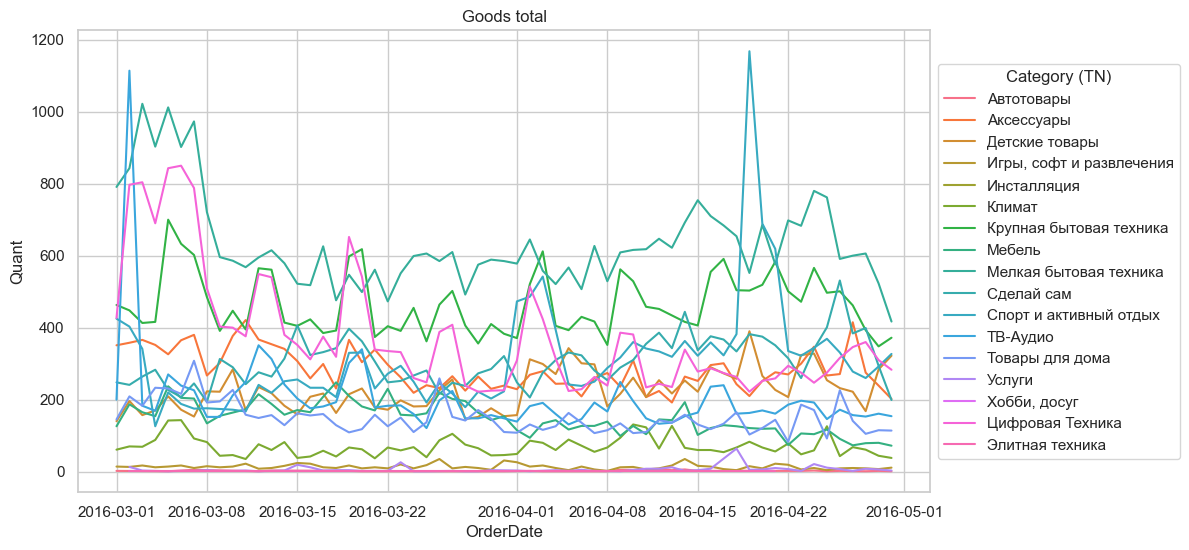

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

placed = df[['TN', 'OrderDate', 'Quant', 'RowSum']].groupby(['TN', 'OrderDate']).sum().reset_index()
placed['OrderDate'] = pd.to_datetime(placed['OrderDate'])

sns.set(style="whitegrid")
plt.figure(figsize=(11, 6))
sns.lineplot(data=placed, x='OrderDate', y='Quant', hue='TN')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Category (TN)")
plt.title('Goods total')


Text(0.5, 1.0, 'Goods sold')

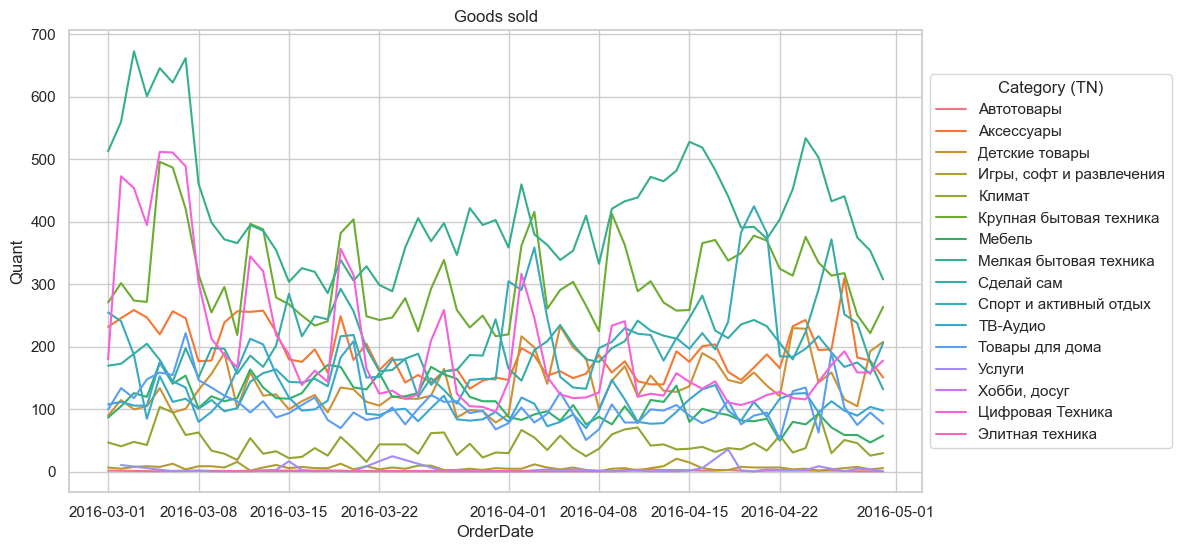

In [6]:
sold = df[df['Status_ID'] == 14][['TN', 'OrderDate', 'Quant']].groupby(['TN', 'OrderDate']).sum().reset_index()
sold['OrderDate'] = pd.to_datetime(sold['OrderDate'])

plt.figure(figsize=(11, 6))
sns.lineplot(data=sold, x='OrderDate', y='Quant', hue='TN')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Category (TN)")
plt.title('Goods sold')


In [7]:
actions_values = df['Actions'].value_counts().index
actions_set = set()
for action in actions_values:
    values = action.split(',')
    for value in values:
        actions_set.add(value)

for col in list(actions_set):
    df[col] = df['Actions'].apply(lambda x: int(str(x).find(col) != -1))
df['Quant_action'] = df['Quant'] * df['СкидкаСуммойПроцентомСЛимитом']

## Крупная бытовая техника

In [8]:
category_name = 'Крупная бытовая техника'

placed1 = df_clustering_1[(df_clustering_1['TN'] == f'{category_name}') & (df_clustering_1['cluster'] == 0)][['OrderDate', 'Quant', 'RowSum']].\
    groupby(['OrderDate']).sum()
daily_sales = placed1.resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']


action = df[df['TN'] == 'Крупная бытовая техника'][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(60)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,202,13378.064356,1,1,0,1
2016-03-02,234,12255.025641,2,2,0,1
2016-03-03,185,12619.059459,3,3,0,1
2016-03-04,186,13158.220430,4,4,0,1
2016-03-05,337,11977.679525,5,5,1,1
2016-03-06,271,12306.095941,6,6,1,1
2016-03-07,263,11836.942966,0,7,0,1
2016-03-08,232,12517.974138,1,8,0,1
2016-03-09,196,12218.647959,2,9,0,1


In [9]:
from ipywidgets import IntProgress

from itertools import product
def percentile(n):
    '''Calculate n - percentile of data'''
    def percentile_(x):
        return np.percentile(x, n)
    percentile_.__name__ = 'pctl%s' % n
    return percentile_

# add missing dates to GroupBy.Core object
def fill_missing_dates(x, date_col, freq = None, default_value = np.nan):

    if freq is None:
        try:
           freq = pd.infer_freq(x.set_index(date_col).index[:min(100, x.shape[0])])
        except:
           freq = 'D'

        if freq is None:
          freq = 'D'
          Warning('TS freq is not defined! Daily granularity is provided!')
    # print(freq)
    # new indexes without time breaks
    idx = pd.date_range(x[date_col].min(), x[date_col].max(), freq=freq)
    # print(idx)
    results = x.set_index(date_col).reindex(idx,fill_value = default_value)
    results.index.rename(date_col, inplace = True)

    # groupby_day = x.groupby(pd.PeriodIndex(x[date_col], freq='D'))
    # results = groupby_day.sum(min_count=1)

    # idx = pd.period_range(min_date, max_date)
    # results = results.reindex(idx, fill_value=default_value)

    # results.index.rename(date_col, inplace=True)

    return results.reset_index()


def calc_preag_fill(data, group_col, date_col, target_cols, preagg_method):
    ## calc preaggregation
    data_preag = data.groupby(group_col).agg(
        preagg_method)[target_cols].reset_index()

    ## fill missing dates
    data_preag_filled = data_preag.groupby(group_col[:-1]).apply(
         fill_missing_dates, date_col=date_col).drop(group_col[:-1],
                                                     axis=1).reset_index()

    ## return DataFrame with calculated preaggregation and filled missing dates
    return data_preag # ,  data_preag_filled


def calc_rolling(data_preag_filled, group_col, date_col, method, w):

    ## calc rolling stats
    lf_df_filled = data_preag_filled.groupby(group_col[:-1]).\
        apply(lambda x: x.set_index(date_col).rolling(window=w, min_periods=1).agg(method)).drop(group_col[:-1], axis=1).reset_index(group_col)

    ## return DataFrame with rolled columns from target_vars
    return lf_df_filled

# ewma calculation method
def calc_ewm(data_preag_filled, group_col, date_col, span):
    ## calc ewm stats
    lf_df_filled = data_preag_filled.groupby(group_col[:-1]).\
        apply(lambda x: x.set_index(date_col).ewm(span=span).mean()).drop(group_col[:-1], axis=1).reset_index(group_col)

    ## return DataFrame with rolled columns from target_vars
    return lf_df_filled

# shift ts data
def shift(lf_df_filled, group_col, date_col, lag, kwargs = None):

    lf_df = (lf_df_filled.     # prepare calculations
        set_index(date_col).    # date column as time-index
        groupby(group_col[:-1]).       # ids_col to separate different time series
        apply(lambda x: x.shift(lag, kwargs)).    # aplly shift at lag steps
        drop(group_col[:-1], axis=1).                   # drop ids_col from time df to reset index
        reset_index()              # reset index to return df to no-index state
    )
    # lf_df[date_col] = pd.to_datetime(lf_df[date_col].astype(str))
    # print(lf_df.index)

    ## return DataFrame with following columns: filter_col, id_cols, date_col and shifted stats
    return lf_df


def generate_lagged_features(
        data: pd.DataFrame,
        target_cols: list = ['Demand'],
        id_cols: list = ['SKU_id', 'Store_id'],
        date_col: str = 'Date',
        lags: list = [7, 14, 21, 28],
        windows: list = ['7D', '14D', '28D', '56D'],
        preagg_methods: list = ['mean'],
        agg_methods: list = ['mean', 'median', percentile(10), pd.Series.skew],
        dynamic_filters: list = ['weekday', 'Promo'],
        ewm_params: dict = {'weekday': [14, 28], 'Promo': [14, 42]}) -> pd.DataFrame:

    '''
    data - dataframe with default index
    target_cols - column names for lags calculation
    id_cols - key columns to identify unique values
    date_col - column with datetime format values
    lags - lag values(days)
    windows - windows(days/weeks/months/etc.),
        calculation is performed within time range length of window
    preagg_methods - applied methods before rolling to make
        every value unique for given id_cols
    agg_methods - method of aggregation('mean', 'median', percentile, etc.)
    dynamic_filters - column names to use as filter
    ewm_params - span values(days) for each dynamic_filter
    '''

    data = data.sort_values(date_col)
    out_df = deepcopy(data)
    dates = [min(data[date_col]), max(data[date_col])]

    total = len(target_cols) * len(lags) * len(windows) * len(preagg_methods) * len(agg_methods) * len(dynamic_filters)
    progress = IntProgress(min=0, max=total)
    display(progress)

    for filter_col in dynamic_filters:
        group_col = [filter_col] + id_cols + [date_col]
        for preagg in preagg_methods:
          data_preag_filled = calc_preag_fill(data, group_col, date_col,
                                                  target_cols, preagg)

          ## add ewm features
          for alpha in ewm_params.get(filter_col, []):
              ewm_filled = calc_ewm(data_preag_filled, group_col,
                                    date_col, alpha)
              for lag in lags:
                ewm = shift(ewm_filled, group_col, date_col, lag)

                new_names = {x: "{0}_lag{1}d_alpha{2}_key{3}_preag{4}_{5}_dynamic_ewm".\
                    format(x, lag, alpha, '&'.join(id_cols), preagg, filter_col) for x in target_cols}

                out_df = pd.merge(out_df,
                                  ewm.rename(columns=new_names),
                                  how='left',
                                  on=group_col)

          ## add rolling features
          for w in windows:
              for method in agg_methods:
                  rolling_filled = calc_rolling(data_preag_filled,
                                                group_col, date_col,
                                                method, w)
                  for lag in lags:
                    ## lf_df - DataFrame with following columns: filter_col, id_cols, date_col, shifted rolling stats
                    rolling = shift(rolling_filled, group_col, date_col, lag)

                    method_name = method.__name__ if type(
                        method) != str else method

                    new_names = {x: "{0}_lag{1}d_w{2}_key{3}_preag{4}_ag{5}_{6}_dynamic_rolling".\
                                  format(x, lag, w, '&'.join(id_cols), preagg, method_name, filter_col) for x in target_cols}

                    out_df = pd.merge(out_df,
                                      rolling.rename(columns=new_names),
                                      how='left',
                                      on=group_col)
                    progress.value += 1

    return out_df

In [10]:
target_cols = ['Quant']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['mean'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )

data_lagged_features

IntProgress(value=0, max=12)

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,IsAction,NoFilter,Quant_lag14d_alpha14_key_preagmean_NoFilter_dynamic_ewm,Quant_lag20d_alpha14_key_preagmean_NoFilter_dynamic_ewm,...,Quant_lag14d_w14D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w14D_key_preagmean_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagmean_agpctl90_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagmean_agmean_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagmean_agmean_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagmean_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagmean_agpctl90_NoFilter_dynamic_rolling
0,2016-03-01,202,13378.064356,1,1,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,234,12255.025641,2,2,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,185,12619.059459,3,3,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,186,13158.220430,4,4,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,337,11977.679525,5,5,1,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,235,12052.187234,1,26,0,0,1,209.675974,208.049207,...,174.2,173.2,235.9,238.7,205.45,209.35,171.8,175.6,238.1,277.1
57,2016-04-27,220,12805.545455,2,27,0,0,1,211.322211,206.301713,...,174.2,173.2,235.9,238.7,206.05,210.05,171.8,175.6,238.1,277.1
58,2016-04-28,180,12580.438889,3,28,0,0,1,212.347554,200.907822,...,176.9,171.8,235.9,238.7,208.40,204.50,175.4,171.8,238.1,242.9
59,2016-04-29,159,12956.842767,4,29,0,0,1,212.434667,204.933261,...,193.3,171.8,235.9,238.7,208.35,202.15,175.4,171.8,238.1,238.1


In [11]:
train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

In [12]:
train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)

In [13]:
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

In [14]:
print(X.dtypes)

categorical_features_indices = np.where(X.dtypes != float)[0]

RowSum                                                               float64
weekday                                                                int32
monthday                                                               int32
is_weekend                                                             int64
IsAction                                                               int64
NoFilter                                                               int64
Quant_lag14d_alpha14_key_preagmean_NoFilter_dynamic_ewm              float64
Quant_lag20d_alpha14_key_preagmean_NoFilter_dynamic_ewm              float64
Quant_lag14d_alpha28_key_preagmean_NoFilter_dynamic_ewm              float64
Quant_lag20d_alpha28_key_preagmean_NoFilter_dynamic_ewm              float64
Quant_lag14d_w14D_key_preagmean_agmean_NoFilter_dynamic_rolling      float64
Quant_lag20d_w14D_key_preagmean_agmean_NoFilter_dynamic_rolling      float64
Quant_lag14d_w14D_key_preagmean_agpctl10_NoFilter_dynamic_rolling    float64

In [15]:
from catboost import CatBoostRegressor, Pool, metrics, cv
from sklearn.metrics import mean_squared_error

In [16]:
model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

In [17]:
model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [18]:
X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
predictions

array([226.59719194, 208.67559329, 196.93521263, 211.86250544,
       207.72518172, 196.23313524, 243.82773124, 248.37794264,
       208.90484785, 215.59427755, 194.9515571 , 190.80542368,
       192.16283118, 227.64744584])

In [19]:
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,NoFilter,Predictions
OrderDate,,,,,,,,
2016-03-01,202,13378.064356,1,1,0,1,1,-1.000000
2016-03-02,234,12255.025641,2,2,0,1,1,-1.000000
2016-03-03,185,12619.059459,3,3,0,1,1,-1.000000
2016-03-04,186,13158.220430,4,4,0,1,1,-1.000000
2016-03-05,337,11977.679525,5,5,1,1,1,-1.000000
...,...,...,...,...,...,...,...,...
2016-04-26,235,12052.187234,1,26,0,0,1,215.594278
2016-04-27,220,12805.545455,2,27,0,0,1,194.951557
2016-04-28,180,12580.438889,3,28,0,0,1,190.805424


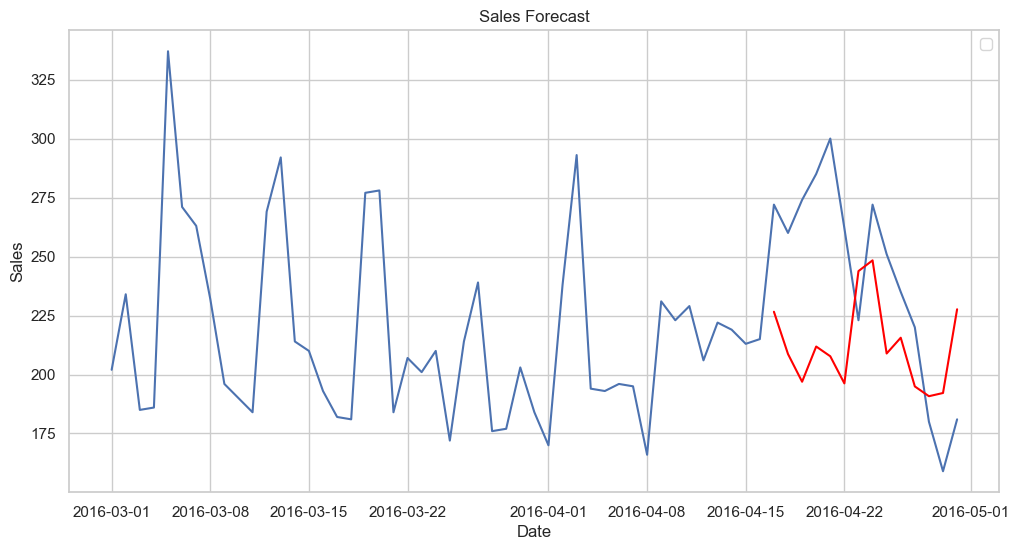

MAE: 44.756141896487165
MSE: 2570.280427515495
MAPE: 18.08225531285573


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

In [21]:
category_name = 'Крупная бытовая техника'

placed1 = df_clustering_1[(df_clustering_1['TN'] == f'{category_name}') & (df_clustering_1['cluster'] == 5)][['OrderDate', 'Quant', 'RowSum']].\
    groupby(['OrderDate']).sum()
daily_sales = placed1.resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']


action = df[df['TN'] == 'Крупная бытовая техника'][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(60)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,164,25360.676829,1,1,0,1
2016-03-02,148,23975.452703,2,2,0,1
2016-03-03,140,24371.785714,3,3,0,1
2016-03-04,133,24569.150376,4,4,0,1
2016-03-05,228,25746.394737,5,5,1,1
2016-03-06,217,26665.221198,6,6,1,1
2016-03-07,211,23445.739336,0,7,0,1
2016-03-08,167,23268.586826,1,8,0,1
2016-03-09,118,24104.838983,2,9,0,1


In [22]:
target_cols = ['Quant']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14] # min(lags)>= forecast horizon!
                    , windows = ['14D']
                    , preagg_methods = ['mean'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )

data_lagged_features

IntProgress(value=0, max=3)

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,IsAction,NoFilter,Quant_lag14d_alpha14_key_preagmean_NoFilter_dynamic_ewm,Quant_lag14d_alpha28_key_preagmean_NoFilter_dynamic_ewm,Quant_lag14d_w14D_key_preagmean_agmean_NoFilter_dynamic_rolling,Quant_lag14d_w14D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w14D_key_preagmean_agpctl90_NoFilter_dynamic_rolling
0,2016-03-01,164,25360.676829,1,1,0,1,1,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,148,23975.452703,2,2,0,1,1,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,140,24371.785714,3,3,0,1,1,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,133,24569.150376,4,4,0,1,1,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,228,25746.394737,5,5,1,1,1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,150,27088.506667,1,26,0,0,1,138.053366,140.165449,135.928571,109.1,167.5
57,2016-04-27,144,25584.215278,2,27,0,0,1,135.107489,138.423798,135.714286,109.1,167.5
58,2016-04-28,138,24637.565217,3,28,0,0,1,133.357028,137.243769,136.214286,109.1,167.5
59,2016-04-29,104,24766.490385,4,29,0,0,1,131.173068,135.793461,136.928571,114.6,167.5


In [23]:
train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

In [24]:
train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)

In [25]:
from catboost import CatBoostRegressor, Pool, metrics, cv
from sklearn.metrics import mean_squared_error

In [26]:
model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

In [27]:
model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [28]:
X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
predictions

CatBoostError: catboost/libs/data/model_dataset_compatibility.cpp:81: At position 7 should be feature with name Quant_lag20d_alpha14_key_preagmean_NoFilter_dynamic_ewm (found Quant_lag14d_alpha28_key_preagmean_NoFilter_dynamic_ewm).

In [29]:
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,NoFilter,Predictions
OrderDate,,,,,,,,
2016-03-01,164,25360.676829,1,1,0,1,1,-1.000000
2016-03-02,148,23975.452703,2,2,0,1,1,-1.000000
2016-03-03,140,24371.785714,3,3,0,1,1,-1.000000
2016-03-04,133,24569.150376,4,4,0,1,1,-1.000000
2016-03-05,228,25746.394737,5,5,1,1,1,-1.000000
...,...,...,...,...,...,...,...,...
2016-04-26,150,27088.506667,1,26,0,0,1,215.594278
2016-04-27,144,25584.215278,2,27,0,0,1,194.951557
2016-04-28,138,24637.565217,3,28,0,0,1,190.805424


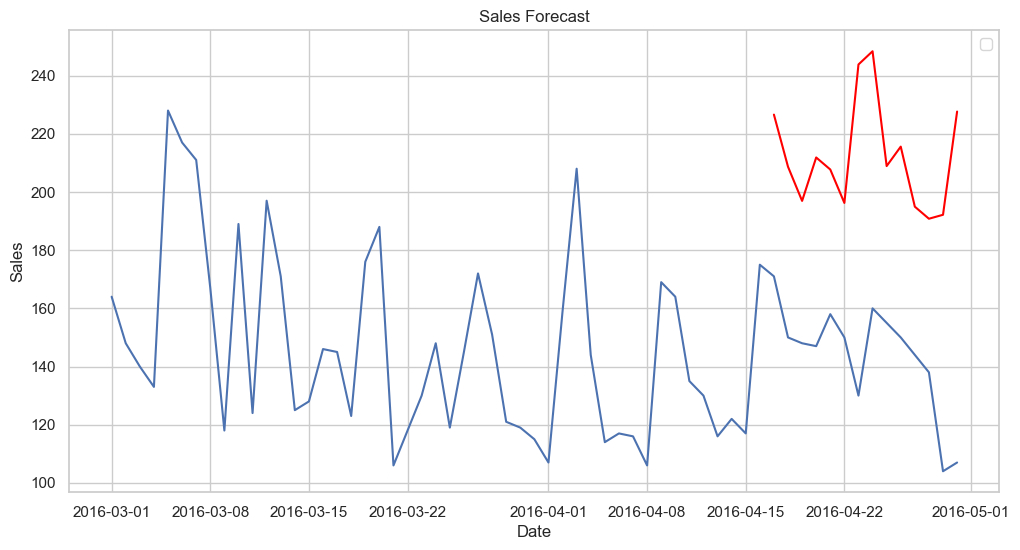

MAE: 68.4500626672996
MSE: 5245.320648712922
MAPE: 50.25639272559391


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Мелкая бытовая техника

In [31]:
category_name = 'Мелкая бытовая техника'

placed1 = df_clustering_1[(df_clustering_1['TN'] == f'{category_name}') & (df_clustering_1['cluster'] == 0)][['OrderDate', 'Quant', 'RowSum']].set_index('OrderDate')
daily_sales = placed1.resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']


action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')
daily_sales.head(60)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,692,3681.135838,1,1,0,1
2016-03-02,736,4002.748641,2,2,0,1
2016-03-03,858,3822.495338,3,3,0,1
2016-03-04,756,4066.550265,4,4,0,1
2016-03-05,814,4140.803440,5,5,1,1
2016-03-06,737,4155.137042,6,6,1,1
2016-03-07,832,3971.050481,0,7,0,1
2016-03-08,611,3590.725041,1,8,0,1
2016-03-09,524,4048.635496,2,9,0,1


In [32]:
target_cols = ['Quant']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['mean'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )
data_lagged_features

IntProgress(value=0, max=12)

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,IsAction,NoFilter,Quant_lag14d_alpha14_key_preagmean_NoFilter_dynamic_ewm,Quant_lag20d_alpha14_key_preagmean_NoFilter_dynamic_ewm,...,Quant_lag14d_w14D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w14D_key_preagmean_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagmean_agpctl90_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagmean_agmean_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagmean_agmean_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagmean_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagmean_agpctl90_NoFilter_dynamic_rolling
0,2016-03-01,692,3681.135838,1,1,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,736,4002.748641,2,2,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,858,3822.495338,3,3,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,756,4066.550265,4,4,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,814,4140.803440,5,5,1,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,478,4208.669456,1,26,0,1,1,463.928301,442.772017,...,410.7,417.3,497.8,476.7,451.50,430.50,416.1,385.5,489.4,470.1
57,2016-04-27,484,4049.745868,2,27,0,1,1,473.422023,438.115498,...,410.7,417.0,525.1,476.7,456.90,431.55,416.1,397.2,505.3,470.1
58,2016-04-28,459,4144.058824,3,28,0,1,1,489.524805,432.746529,...,410.7,410.7,559.5,476.7,465.00,428.85,416.1,395.4,538.5,470.1
59,2016-04-29,423,3992.943262,4,29,0,1,1,507.212648,437.061085,...,410.7,410.7,586.8,476.7,474.60,433.50,416.1,399.8,572.4,470.1


In [33]:
train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

In [ ]:
train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

In [ ]:
model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

In [ ]:
model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [28]:
X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
predictions

array([596.73528377, 597.43771612, 556.61390953, 559.55019096,
       548.862027  , 574.47646096, 569.76073116, 561.92566448,
       558.27943525, 558.30255802, 513.97573466, 543.09091009,
       546.82244038, 488.45235333])

In [29]:
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,NoFilter,Predictions
OrderDate,,,,,,,,
2016-03-01,692,3681.135838,1,1,0,1,1,-1.000000
2016-03-02,736,4002.748641,2,2,0,1,1,-1.000000
2016-03-03,858,3822.495338,3,3,0,1,1,-1.000000
2016-03-04,756,4066.550265,4,4,0,1,1,-1.000000
2016-03-05,814,4140.803440,5,5,1,1,1,-1.000000
...,...,...,...,...,...,...,...,...
2016-04-26,478,4208.669456,1,26,0,1,1,558.302558
2016-04-27,484,4049.745868,2,27,0,1,1,513.975735
2016-04-28,459,4144.058824,3,28,0,1,1,543.090910


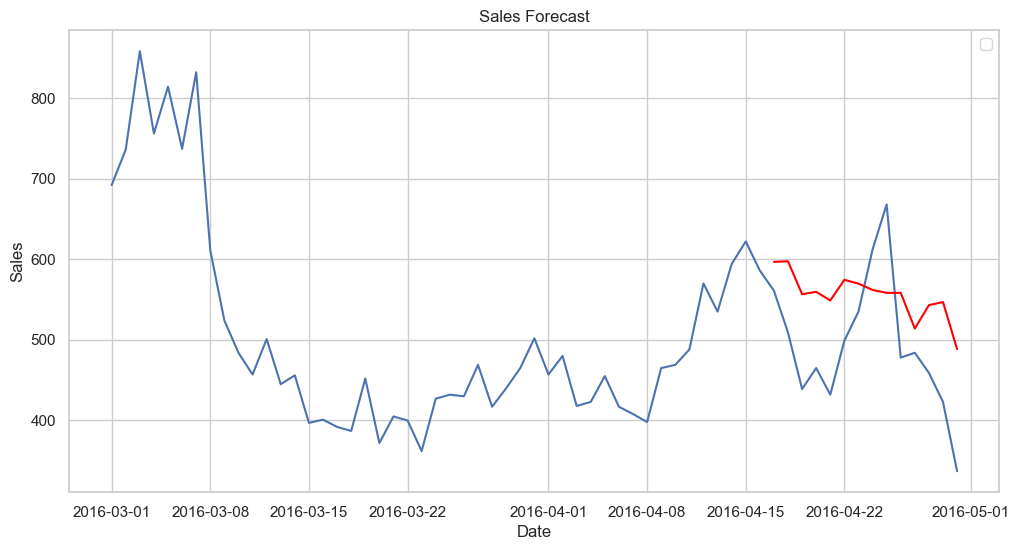

MAE: 85.2053725899236
MSE: 8547.637752873738
MAPE: 18.54844959450448


In [30]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

In [31]:
category_name = 'Мелкая бытовая техника'

placed1 = df_clustering_1[(df_clustering_1['TN'] == f'{category_name}') & (df_clustering_1['cluster'] == 5)][['OrderDate', 'Quant', 'RowSum']].set_index('OrderDate')
daily_sales = placed1.resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']


action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')
daily_sales.head(60)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,37,6668.432432,1,1,0,1
2016-03-02,57,8138.543860,2,2,0,1
2016-03-03,61,8295.032787,3,3,0,1
2016-03-04,56,10797.625000,4,4,0,1
2016-03-05,69,11193.028986,5,5,1,1
2016-03-06,58,10618.103448,6,6,1,1
2016-03-07,73,8958.643836,0,7,0,1
2016-03-08,45,6507.955556,1,8,0,1
2016-03-09,49,12304.653061,2,9,0,1


In [32]:
target_cols = ['Quant']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['mean'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )
data_lagged_features

IntProgress(value=0, max=12)

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,IsAction,NoFilter,Quant_lag14d_alpha14_key_preagmean_NoFilter_dynamic_ewm,Quant_lag20d_alpha14_key_preagmean_NoFilter_dynamic_ewm,...,Quant_lag14d_w14D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w14D_key_preagmean_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagmean_agpctl90_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagmean_agmean_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagmean_agmean_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagmean_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagmean_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagmean_agpctl90_NoFilter_dynamic_rolling
0,2016-03-01,37,6668.432432,1,1,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,57,8138.543860,2,2,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,61,8295.032787,3,3,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,56,10797.625000,4,4,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,69,11193.028986,5,5,1,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,40,7657.700000,1,26,0,1,1,55.379409,50.959018,...,37.0,37.0,69.4,71.4,57.25,52.00,37.0,35.0,70.2,70.2
57,2016-04-27,62,6649.919355,2,27,0,1,1,55.061569,53.107158,...,37.0,37.0,69.4,71.4,56.80,53.30,37.0,35.0,70.2,70.2
58,2016-04-28,94,9402.053191,3,28,0,1,1,54.786253,51.620600,...,37.0,37.0,69.4,71.4,55.95,53.70,37.0,36.8,70.2,70.2
59,2016-04-29,46,14507.913043,4,29,0,1,1,56.283492,53.811678,...,37.0,37.0,69.4,69.4,54.50,55.05,37.0,36.8,68.2,70.2


In [33]:
train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

In [34]:
train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

In [35]:
model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

In [36]:
model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [37]:
X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
predictions

array([56.74314216, 59.07994756, 60.9257858 , 55.3497355 , 58.02833873,
       58.07042239, 65.43639607, 57.77740099, 54.27869199, 54.08351025,
       56.08089586, 56.3574347 , 54.87497176, 60.19908918])

In [38]:
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,NoFilter,Predictions
OrderDate,,,,,,,,
2016-03-01,37,6668.432432,1,1,0,1,1,-1.000000
2016-03-02,57,8138.543860,2,2,0,1,1,-1.000000
2016-03-03,61,8295.032787,3,3,0,1,1,-1.000000
2016-03-04,56,10797.625000,4,4,0,1,1,-1.000000
2016-03-05,69,11193.028986,5,5,1,1,1,-1.000000
...,...,...,...,...,...,...,...,...
2016-04-26,40,7657.700000,1,26,0,1,1,54.083510
2016-04-27,62,6649.919355,2,27,0,1,1,56.080896
2016-04-28,94,9402.053191,3,28,0,1,1,56.357435


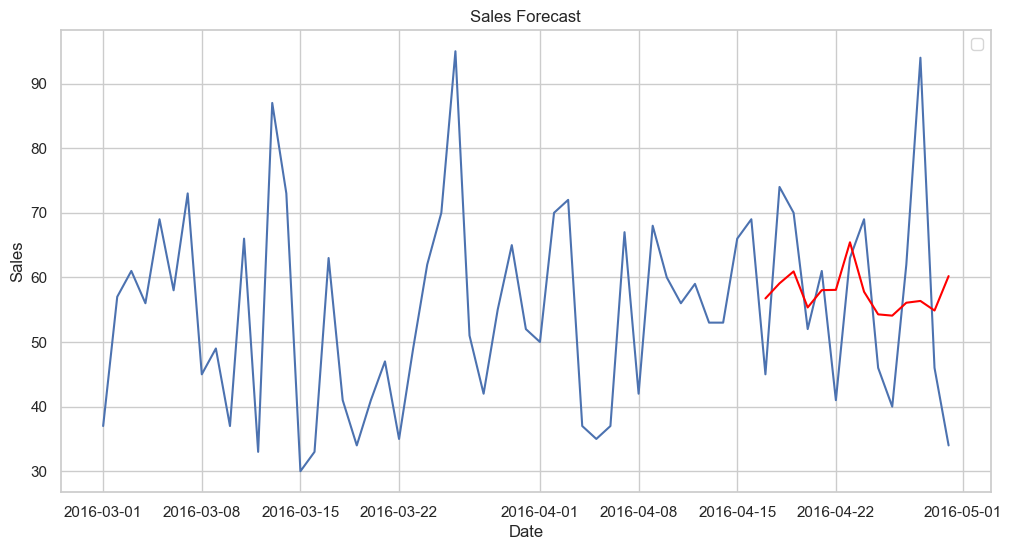

MAE: 12.41329683392946
MSE: 240.73015753057763
MAPE: 23.67496205320365


In [39]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

In [30]:
category_name = 'Цифровая Техника'

placed1 = placed[placed['TN'] == f'{category_name}'][['OrderDate', 'Quant', 'RowSum']].set_index('OrderDate')
daily_sales = placed1.resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']

action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')
daily_sales.head(60)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,427,14742.857143,1,1,0,1
2016-03-02,797,14608.587202,2,2,0,1
2016-03-03,804,16179.733831,3,3,0,1
2016-03-04,690,17465.007246,4,4,0,1
2016-03-05,843,12599.801898,5,5,1,1
2016-03-06,850,12129.991765,6,6,1,1
2016-03-07,788,11696.963198,0,7,0,1
2016-03-08,509,13541.442043,1,8,0,1
2016-03-09,403,17078.071960,2,9,0,1


In [31]:
target_cols = ['Quant']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['sum'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )
data_lagged_features

IntProgress(value=0, max=12)

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,IsAction,NoFilter,Quant_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm,Quant_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm,...,Quant_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling
0,2016-03-01,427,14742.857143,1,1,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,797,14608.587202,2,2,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,804,16179.733831,3,3,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,690,17465.007246,4,4,0,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,843,12599.801898,5,5,1,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,316,18647.648734,1,26,0,0,1,301.006732,317.841022,...,225.3,224.3,412.6,419.2,298.85,337.45,224.9,224.9,409.6,516.8
57,2016-04-27,346,16295.572254,2,27,0,0,1,292.189585,310.496947,...,226.9,224.3,412.6,419.2,297.60,334.65,224.9,224.9,409.6,516.8
58,2016-04-28,360,17960.772222,3,28,0,0,1,298.440958,300.927955,...,230.5,224.3,412.6,419.2,302.15,314.00,224.9,224.9,409.6,433.0
59,2016-04-29,310,18235.893548,4,29,0,0,1,295.711720,312.308067,...,230.5,224.3,412.6,419.2,296.65,306.20,224.9,224.9,409.6,409.6


In [32]:
train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

In [33]:
model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [34]:
X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
predictions

array([405.21479367, 372.81969519, 423.21743268, 427.53204444,
       380.0174531 , 431.26117138, 339.35576156, 353.97718572,
       368.63674302, 393.66176084, 450.99952935, 401.15670406,
       446.35154066, 366.70286508])

In [35]:
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,NoFilter,Predictions
OrderDate,,,,,,,,
2016-03-01,427,14742.857143,1,1,0,1,1,-1.000000
2016-03-02,797,14608.587202,2,2,0,1,1,-1.000000
2016-03-03,804,16179.733831,3,3,0,1,1,-1.000000
2016-03-04,690,17465.007246,4,4,0,1,1,-1.000000
2016-03-05,843,12599.801898,5,5,1,1,1,-1.000000
...,...,...,...,...,...,...,...,...
2016-04-26,316,18647.648734,1,26,0,0,1,393.661761
2016-04-27,346,16295.572254,2,27,0,0,1,450.999529
2016-04-28,360,17960.772222,3,28,0,0,1,401.156704


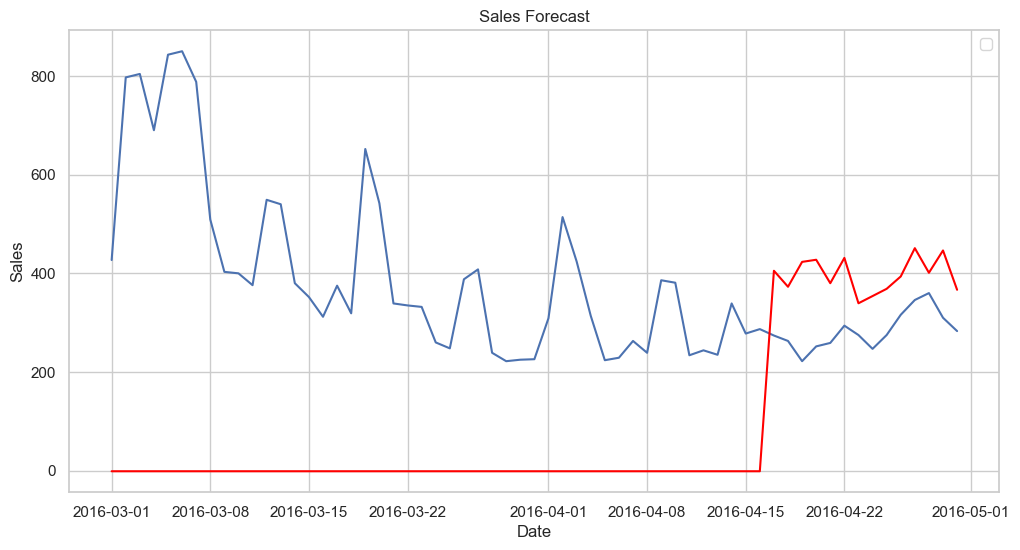

MAE: 113.2074771955811
MSE: 14483.225232511153
MAPE: 41.71649618086804


In [36]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index, daily_sales.Predictions, color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Сделай Сам

In [34]:
category_name = 'Сделай сам'

placed1 = df_clustering_1[(df_clustering_1['TN'] == f'{category_name}') & (df_clustering_1['cluster'] == 0)][['OrderDate', 'Quant', 'RowSum']].set_index('OrderDate')
daily_sales = placed1.resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']


action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')
daily_sales.head(60)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,201,5540.547264,1,1,0,0
2016-03-02,202,5489.787129,2,2,0,0
2016-03-03,230,5292.291304,3,3,0,0
2016-03-04,234,4369.564103,4,4,0,1
2016-03-05,193,4196.937824,5,5,1,1
2016-03-06,168,5124.041667,6,6,1,1
2016-03-07,180,4351.600000,0,7,0,1
2016-03-08,155,4831.219355,1,8,0,1
2016-03-09,257,4528.315175,2,9,0,0


In [35]:
target_cols = ['Quant']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['sum'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )

train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
predictions

IntProgress(value=0, max=12)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

array([231.63810792, 214.5127304 , 217.24473132, 209.14386952,
       211.91019338, 204.57026184, 197.54576493, 206.06373804,
       212.72217963, 225.48515429, 215.69141396, 216.96608306,
       233.6746983 , 217.49418297])

In [36]:
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,NoFilter,Predictions
OrderDate,,,,,,,,
2016-03-01,201,5540.547264,1,1,0,0,1,-1.000000
2016-03-02,202,5489.787129,2,2,0,0,1,-1.000000
2016-03-03,230,5292.291304,3,3,0,0,1,-1.000000
2016-03-04,234,4369.564103,4,4,0,1,1,-1.000000
2016-03-05,193,4196.937824,5,5,1,1,1,-1.000000
...,...,...,...,...,...,...,...,...
2016-04-26,422,4898.656398,1,26,0,1,1,225.485154
2016-04-27,314,5272.009554,2,27,0,1,1,215.691414
2016-04-28,282,5283.099291,3,28,0,1,1,216.966083


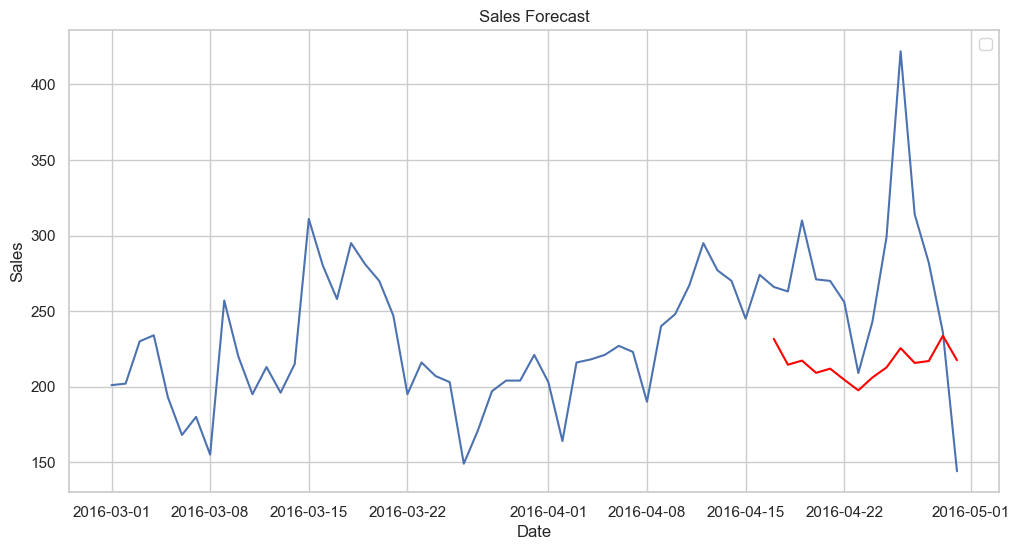

MAE: 65.52323259784036
MSE: 6345.653107728219
MAPE: 23.442966607437864


In [37]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

In [38]:
category_name = 'Сделай сам'

placed1 = df_clustering_1[(df_clustering_1['TN'] == f'{category_name}') & (df_clustering_1['cluster'] == 5)][['OrderDate', 'Quant', 'RowSum']].set_index('OrderDate')
daily_sales = placed1.resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']


action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')
daily_sales.head(60)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,39,12091.384615,1,1,0,0
2016-03-02,23,9650.956522,2,2,0,0
2016-03-03,29,16292.310345,3,3,0,0
2016-03-04,35,11922.600000,4,4,0,1
2016-03-05,28,12649.642857,5,5,1,1
2016-03-06,31,8881.129032,6,6,1,1
2016-03-07,38,9925.657895,0,7,0,1
2016-03-08,31,4696.935484,1,8,0,1
2016-03-09,52,8061.692308,2,9,0,0


In [39]:
target_cols = ['Quant']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['sum'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )

train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
predictions

IntProgress(value=0, max=12)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

array([59.55151177, 55.89695957, 51.56593653, 50.08073114, 49.31012442,
       50.26062451, 49.43517301, 54.2815728 , 54.34722654, 59.24985099,
       53.23038798, 59.1220775 , 58.73157995, 52.77181496])

In [40]:
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,NoFilter,Predictions
OrderDate,,,,,,,,
2016-03-01,39,12091.384615,1,1,0,0,1,-1.000000
2016-03-02,23,9650.956522,2,2,0,0,1,-1.000000
2016-03-03,29,16292.310345,3,3,0,0,1,-1.000000
2016-03-04,35,11922.600000,4,4,0,1,1,-1.000000
2016-03-05,28,12649.642857,5,5,1,1,1,-1.000000
...,...,...,...,...,...,...,...,...
2016-04-26,86,10196.732558,1,26,0,1,1,59.249851
2016-04-27,51,19446.392157,2,27,0,1,1,53.230388
2016-04-28,75,10289.760000,3,28,0,1,1,59.122077


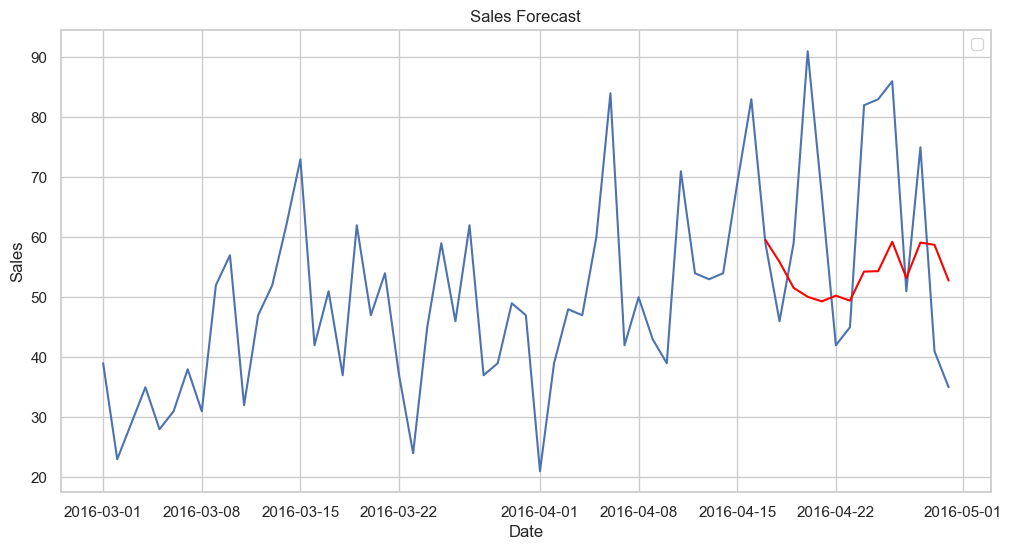

MAE: 16.137180844541135
MSE: 387.20990755733686
MAPE: 25.352897626243344


In [41]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')